# Task 3: Jointly trained soft mixture-of-experts restoration

This notebook turns the Task 2 hard-routing system into a differentiable soft mixture of experts (MoE):

`w = softmax(g(x~) / T)`, `x_hat = w0*x~ + w1*E_salt(x~) + w2*E_blur(x~) + w3*E_occ(x~)`

**Requirements before running**

1. The Task 1 notebook has been run at least through Section 3, so these exist on Drive under `genai-assignment1/`: `common/` (shared code), `data/pets_128.npz`, `data/split_seed42.json`, `manifests/val_manifest.json`, `manifests/test_manifest.json`.
2. Task 2 is finished and its checkpoints are in `genai-assignment1/task2/checkpoints/` (names in Section 2). Task 3 is not allowed to start from random components.
3. Runtime > Change runtime type > T4 GPU. Colab secret `WANDB_API_KEY` set (same as Task 1).

| Section | What it does | Approx. time on T4 |
|---|---|---|
| 1 to 4 | Setup, data, load and check Task 2 components | 5 min |
| 5 | Optuna search (20 trials, warm-up + joint, with pruning) | 90 to 150 min |
| 6 | Final training (gate warm-up, then joint fine-tuning, early stopping) | 40 to 70 min |
| 7 | Test evaluation: soft MoE vs hard routing (predicted and oracle) | 5 to 10 min |
| 8 | Routing analysis (heatmaps, inactive or dominant experts, mixed corruptions) | 5 min |
| 9 | Visual results and failure cases | 2 min |
| 10 to 11 | ONNX export, verification, latency, W&B artefacts | 5 min |

Every output goes to Drive, and the Optuna study is stored in SQLite, so you can rerun cells after a disconnect without losing work.

## 1. Setup

In [1]:
!nvidia-smi -L || echo "No GPU found: Runtime > Change runtime type > T4 GPU"
!pip -q install optuna wandb onnx onnxscript onnxruntime pytorch-msssim

GPU 0: Tesla T4 (UUID: GPU-df3e5b74-3b5d-5ca4-eb7f-ce24f6342c7f)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 22.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT_DIR = "/content/drive/MyDrive/genai-assignment1"
for d in ["task3/checkpoints", "task3/onnx", "task3/figures", "task3/results", "task3/optuna"]:
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print("Working in", os.getcwd())

Mounted at /content/drive
Working in /content/drive/.shortcut-targets-by-id/1KT5qDIAeDn9u5oyeFSbKKbQmUiJ-SsIw/genai-assignment1


In [3]:
import json, random, time, glob, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = 128
DATA_ROOT = "/content/pets_raw"
CACHE_PATH = f"{PROJECT_DIR}/data/pets_128.npz"
SPLIT_PATH = f"{PROJECT_DIR}/data/split_seed42.json"
VAL_MANIFEST = f"{PROJECT_DIR}/manifests/val_manifest.json"
TEST_MANIFEST = f"{PROJECT_DIR}/manifests/test_manifest.json"
T2 = f"{PROJECT_DIR}/task2"
T3 = f"{PROJECT_DIR}/task3"

# Task 2 checkpoints (edit the names if yours differ)
CLASSIFIER_CKPT = f"{T2}/checkpoints/classifier_best.pt"
SPECIALIST_CKPTS = {
    "salt_pepper":   f"{T2}/checkpoints/specialist_salt_pepper_best.pt",
    "gaussian_blur": f"{T2}/checkpoints/specialist_gaussian_blur_best.pt",
    "occlusion":     f"{T2}/checkpoints/specialist_occlusion_best.pt",
}
# Only needed if your Task 2 checkpoints are bare state_dicts without a "config" entry
CLASSIFIER_CFG_OVERRIDE = None     # e.g. {"channels": [32, 64, 128, 256], "dropout": 0.3}
SPECIALIST_CFG_OVERRIDE = None     # e.g. {"base_channels": 32, "latent_channels": 32, "dropout": 0.1}

WANDB_PROJECT = "genai-assignment1"
BATCH_SIZE = 32                    # must be divisible by 4 (balanced batches)
WARMUP_LR = 3e-4                   # gate-only warm-up learning rate
OPTUNA_TRIALS, OPTUNA_WARMUP_EPOCHS, OPTUNA_JOINT_EPOCHS = 20, 1, 4
FINAL_WARMUP_EPOCHS, FINAL_JOINT_EPOCHS, PATIENCE = 3, 35, 8
COLLAPSE_MIN_SHARE = 0.05          # a branch with < 5% average weight on balanced data = collapsed
NUM_WORKERS = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("Device:", device, "| torch", torch.__version__)

Device: cuda | torch 2.11.0+cu130


## 2. Shared code

Task 1 already wrote `common/corruptions.py`, `data.py`, `models.py`, `losses_metrics.py` and `train_utils.py`. This section adds `common/moe.py` (the soft MoE model, losses and balanced sampler). The backend will import the same file.

`common/classifier.py` is the Task 2 classifier class. The cell below writes it **only if it does not exist yet**. If your Task 2 used a different classifier architecture, put that class in `common/classifier.py` under the name `CorruptionClassifier` instead.

In [4]:
%%writefile common/moe.py
"""Task 3: jointly trained soft mixture-of-experts restoration.

Branch order matches CONDITIONS: [clean (identity), salt_pepper, gaussian_blur, occlusion],
so gate output k, routing weight w_k and corruption label k all refer to the same branch.
"""
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Sampler
from pytorch_msssim import ssim

from .corruptions import CONDITIONS, sample_params, apply_corruption

BRANCHES = list(CONDITIONS)
EXPERT_NAMES = BRANCHES[1:]          # salt_pepper, gaussian_blur, occlusion


class SoftMoERestorer(nn.Module):
    """x_hat = w0 * x + w1 * E_salt(x) + w2 * E_blur(x) + w3 * E_occ(x),  w = softmax(g(x) / T)."""

    def __init__(self, gate, experts, temperature=1.0):
        super().__init__()
        assert len(experts) == 3, "expected experts in order: salt_pepper, gaussian_blur, occlusion"
        self.gate = gate
        self.experts = nn.ModuleList(experts)
        self.register_buffer("temperature", torch.tensor(float(temperature)))

    def branch_outputs(self, x):
        """All four branch outputs stacked: (N, 4, 3, H, W). Branch 0 is the identity."""
        return torch.stack([x] + [e(x) for e in self.experts], dim=1)

    def forward(self, x):
        logits = self.gate(x)
        w = torch.softmax(logits / self.temperature, dim=1)
        outs = self.branch_outputs(x)
        x_hat = (w[:, :, None, None, None] * outs).sum(dim=1)
        return x_hat, w, logits


def set_experts_trainable(model, trainable):
    for p in model.experts.parameters():
        p.requires_grad_(trainable)


def balance_loss(w):
    """sum_k (mean_batch(w_k) - 1/K)^2. On a class-balanced batch, perfect routing gives
    mean weights of exactly 1/K, so this term is zero at the ideal solution and only
    penalises collapse onto a subset of branches."""
    k = w.size(1)
    return ((w.mean(dim=0) - 1.0 / k) ** 2).sum()


def moe_loss(x_hat, y, logits, w, labels, lam):
    """L = l1*L1 + ssim*(1 - SSIM) + ce*CE + bal*L_balance.

    CE is computed on the raw gate logits (not logits / T), so the gate stays a calibrated
    corruption classifier and T only controls how sharp the routing is.
    """
    l1 = F.l1_loss(x_hat, y)
    s = ssim(x_hat, y, data_range=1.0, size_average=True)
    ce = F.cross_entropy(logits, labels)
    bal = balance_loss(w)
    total = lam["l1"] * l1 + lam["ssim"] * (1 - s) + lam["ce"] * ce + lam["bal"] * bal
    parts = {"l1": l1.detach(), "ssim": s.detach(), "ce": ce.detach(), "balance": bal.detach()}
    return total, parts


def _chw(img):
    return torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1))).float()


class BalancedRuntimeDataset(Dataset):
    """Indexed by (image_index, condition_index). A fresh severity is sampled for the
    requested condition every time the item is loaded (runtime corruption)."""

    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, key):
        i, c = key
        rng = np.random.default_rng(int(torch.randint(0, 2**31 - 1, (1,)).item()))
        clean = self.images[i].astype(np.float32) / 255.0
        params = sample_params(CONDITIONS[c], rng, *clean.shape[:2])
        return _chw(apply_corruption(clean, params)), _chw(clean), c


class BalancedBatchSampler(Sampler):
    """Every batch has exactly batch_size / 4 images of each condition.
    Each image appears once per epoch; conditions are reshuffled every epoch."""

    def __init__(self, n_images, batch_size, n_classes=4, seed=42):
        assert batch_size % n_classes == 0, "batch size must be divisible by the number of conditions"
        self.n, self.bs, self.k, self.seed, self.epoch = n_images, batch_size, n_classes, seed, 0

    def __len__(self):
        return self.n // self.bs

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        self.epoch += 1
        order = rng.permutation(self.n)
        for b in range(len(self)):
            idx = order[b * self.bs:(b + 1) * self.bs]
            conds = np.repeat(np.arange(self.k), self.bs // self.k)
            rng.shuffle(conds)
            yield [(int(i), int(c)) for i, c in zip(idx, conds)]

Overwriting common/moe.py


In [5]:
CLASSIFIER_SRC = """'''Corruption classifier (Task 2). Used as the gating network in Task 3.

Input: RGB tensor in [0, 1], shape (N, 3, 128, 128). Output: 4 logits in CONDITIONS order.
'''
import torch.nn as nn


class CorruptionClassifier(nn.Module):
    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3, n_classes=4):
        super().__init__()
        layers, cin = [], 3
        for c in channels:
            layers += [nn.Conv2d(cin, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
                       nn.Conv2d(c, c, 3, padding=1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True),
                       nn.MaxPool2d(2)]
            cin = c
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(cin, n_classes))

    def forward(self, x):
        return self.head(self.features(x))
"""
if not os.path.exists("common/classifier.py"):
    with open("common/classifier.py", "w") as f:
        f.write(CLASSIFIER_SRC)
    print("Wrote default common/classifier.py")
else:
    print("Using existing common/classifier.py from Task 2")

Using existing common/classifier.py from Task 2


In [6]:
import importlib
import common.corruptions as cc, common.data as cd, common.models as cm, common.losses_metrics as cl
import common.train_utils as ct, common.classifier as ccls, common.moe as cmoe
for mod in (cc, cd, cm, cl, ct, ccls, cmoe):
    importlib.reload(mod)
from common.corruptions import CONDITIONS, COND2IDX, TEST_LEVELS, apply_corruption
from common.data import prepare_pets_cache, make_or_load_split, ManifestDataset
from common.models import ConvAutoencoder, count_params
from common.losses_metrics import per_sample_metrics, selection_objective
from common.train_utils import make_loader
from common.classifier import CorruptionClassifier
from common.moe import (SoftMoERestorer, set_experts_trainable, moe_loss, BalancedRuntimeDataset,
                        BalancedBatchSampler, BRANCHES, EXPERT_NAMES)
assert BRANCHES == ["clean", "salt_pepper", "gaussian_blur", "occlusion"], BRANCHES
print("Shared modules loaded. Branch order:", BRANCHES)

Shared modules loaded. Branch order: ['clean', 'salt_pepper', 'gaussian_blur', 'occlusion']


## 3. Data, split and manifests (reused from Task 1)

Same 128 x 128 cache, same 80/20 seed-42 split and the same deterministic manifests as Tasks 1 and 2. Nothing is regenerated here, so all three tasks are evaluated on identical inputs.

In [7]:
for p in (CACHE_PATH, SPLIT_PATH, VAL_MANIFEST, TEST_MANIFEST):
    assert os.path.exists(p), f"Missing {p}. Run Task 1 Sections 1 to 3 first."

data = prepare_pets_cache(DATA_ROOT, CACHE_PATH, IMG_SIZE)
trainval_images, trainval_names = data["trainval_images"], data["trainval_names"]
test_images = data["test_images"]
train_idx, val_idx = make_or_load_split(trainval_names, SPLIT_PATH, seed=SEED, train_frac=0.8)
train_images, val_images = trainval_images[train_idx], trainval_images[val_idx]
val_entries = json.load(open(VAL_MANIFEST))["entries"]
test_entries = json.load(open(TEST_MANIFEST))["entries"]
print(f"train {len(train_images)} | val {len(val_images)} ({len(val_entries)} entries) | "
      f"test {len(test_images)} images ({len(test_entries)} entries)")
print("val condition counts:", pd.Series([e['type'] for e in val_entries]).value_counts().to_dict())

val_ds = ManifestDataset(val_images, val_entries)
val_loader = make_loader(val_ds, 128, False, NUM_WORKERS)

train 2944 | val 736 (736 entries) | test 3669 images (36690 entries)
val condition counts: {'occlusion': 184, 'clean': 184, 'salt_pepper': 184, 'gaussian_blur': 184}


## 4. Load the Task 2 components and check them

The gate is initialised from the Task 2 classifier and the three experts from the Task 2 specialists. Before any joint training, this section measures how good they already are on the validation set. These numbers are the starting point you compare against in the report.

In [8]:
def load_ckpt(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(obj, dict):
        for key in ("state_dict", "model_state", "model_state_dict", "model"):
            if key in obj and isinstance(obj[key], dict):
                return obj[key], obj.get("config", obj.get("cfg"))
    return obj, None        # bare state_dict

def build_classifier():
    sd, cfg = load_ckpt(CLASSIFIER_CKPT)
    cfg = CLASSIFIER_CFG_OVERRIDE or cfg
    assert cfg is not None, "Classifier config not found: set CLASSIFIER_CFG_OVERRIDE in Section 1"
    m = CorruptionClassifier(channels=tuple(cfg["channels"]), dropout=cfg.get("dropout", 0.0))
    m.load_state_dict(sd, strict=True)
    return m, cfg

def build_specialist(name):
    sd, cfg = load_ckpt(SPECIALIST_CKPTS[name])
    cfg = SPECIALIST_CFG_OVERRIDE or cfg
    assert cfg is not None, "Specialist config not found: set SPECIALIST_CFG_OVERRIDE in Section 1"
    m = ConvAutoencoder(cfg["base_channels"], cfg["latent_channels"], cfg.get("dropout", 0.0),
                        cfg.get("skip_channels", 0))
    m.load_state_dict(sd, strict=True)
    return m, cfg

for p in [CLASSIFIER_CKPT, *SPECIALIST_CKPTS.values()]:
    assert os.path.exists(p), f"Missing Task 2 checkpoint: {p}"

_, CLASSIFIER_CFG = build_classifier()
SPECIALIST_CFGS = {n: build_specialist(n)[1] for n in EXPERT_NAMES}
print("Classifier config:", CLASSIFIER_CFG)
for n, c in SPECIALIST_CFGS.items():
    print(f"Specialist {n}: {c}")

def build_moe(temperature):
    """Fresh copy of the Task 2 components every time (each Optuna trial starts from the same point)."""
    gate, _ = build_classifier()
    experts = [build_specialist(n)[0] for n in EXPERT_NAMES]
    return SoftMoERestorer(gate, experts, temperature).to(device)

_m = build_moe(1.0)
print(f"Soft MoE parameters: gate {count_params(_m.gate):,} | experts {count_params(_m.experts):,}")
del _m

Classifier config: {'channels': [16, 32, 64, 128], 'dropout': 0.11299312390843377}
Specialist salt_pepper: {'base_channels': 48, 'latent_channels': 16, 'dropout': 0.2191038368562885, 'skip_channels': 0}
Specialist gaussian_blur: {'base_channels': 48, 'latent_channels': 16, 'dropout': 0.2191038368562885, 'skip_channels': 0}
Specialist occlusion: {'base_channels': 48, 'latent_channels': 16, 'dropout': 0.2191038368562885, 'skip_channels': 0}
Soft MoE parameters: gate 295,028 | experts 27,814,809


In [9]:
@torch.no_grad()
def check_task2_components(loader):
    """Classifier accuracy, plus hard routing (predicted and oracle) on the validation manifest."""
    m = build_moe(1.0).eval()
    correct, n, ssim_pred, ssim_oracle = 0, 0, [], []
    for x, y, c, _ in loader:
        x, y, c = x.to(device), y.to(device), c.to(device)
        logits = m.gate(x)
        outs = m.branch_outputs(x)
        pred = logits.argmax(1)
        ar = torch.arange(len(x), device=device)
        correct += (pred == c).sum().item(); n += len(x)
        ssim_pred.append(per_sample_metrics(outs[ar, pred], y)["ssim"].cpu())
        ssim_oracle.append(per_sample_metrics(outs[ar, c], y)["ssim"].cpu())
    return {"classifier_acc": correct / n,
            "hard_pred_ssim": torch.cat(ssim_pred).mean().item(),
            "hard_oracle_ssim": torch.cat(ssim_oracle).mean().item()}

T2_VAL_CHECK = check_task2_components(val_loader)
print("Task 2 components on validation:", {k: round(v, 4) for k, v in T2_VAL_CHECK.items()})

Task 2 components on validation: {'classifier_acc': 0.9986, 'hard_pred_ssim': 0.7831, 'hard_oracle_ssim': 0.7826}


## 5. Training procedure and Optuna search

**Balanced batches.** `BalancedBatchSampler` puts exactly `BATCH_SIZE / 4` images of each condition in every batch, and a new severity is sampled at load time. This matters for the balance loss: on a balanced batch, perfect routing gives average weights of exactly 0.25 per branch, so the balance term is zero at the ideal and only penalises collapse.

**Two stages.**
1. Warm-up: experts frozen (no gradients, BatchNorm statistics fixed in eval mode), only the gate is trained with `WARMUP_LR`. The gate learns to route under the soft combination before the experts start moving.
2. Joint fine-tuning: experts unfrozen, the whole system is trained with the smaller tuned learning rate `lr_joint`.

**Loss.** `L = a*L1 + (1-a)*(1-SSIM) + lambda_ce*CE + lambda_bal*L_balance`. CE uses the raw gate logits, so the gate stays a calibrated classifier and `T` only controls how sharp the routing is.

**Optuna** tunes `lr_joint`, `T`, `lambda_ce`, `lambda_bal` and the reconstruction weighting `a`. As in Task 1, trials are selected on a fixed `val_L1 + (1 - val_SSIM)` objective that does not depend on any tuned loss weight. Trials are pruned when they fall below the median (MedianPruner) or when routing collapses (any branch below `COLLAPSE_MIN_SHARE` average weight on the balanced validation set).

In [10]:
import wandb
os.environ.setdefault("WANDB_SILENT", "true")
try:
    from google.colab import userdata
    wandb.login(key=userdata.get("WANDB_API_KEY"))
except Exception as e:
    print("Colab secret not found, falling back to interactive login:", e)
    wandb.login()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [11]:
import optuna
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

train_ds = BalancedRuntimeDataset(train_images)

def make_train_loader(batch_size, seed):
    return DataLoader(train_ds, batch_sampler=BalancedBatchSampler(len(train_ds), batch_size, seed=seed),
                      num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                      persistent_workers=NUM_WORKERS > 0)

def lambdas(cfg):
    return {"l1": cfg["recon_alpha"], "ssim": 1 - cfg["recon_alpha"],
            "ce": cfg["lambda_ce"], "bal": cfg["lambda_bal"]}

def train_epoch(model, loader, opt, lam, experts_frozen):
    model.train()
    if experts_frozen:
        model.experts.eval()                     # freeze BatchNorm statistics too
    tot, n = {}, 0
    wsum = torch.zeros(4)
    for x, y, c in loader:
        x, y, c = x.to(device, non_blocking=True), y.to(device, non_blocking=True), c.to(device)
        x_hat, w, logits = model(x)
        loss, parts = moe_loss(x_hat, y, logits, w, c, lam)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        b = len(x); n += b
        for k, v in {"loss": loss.detach(), **parts}.items():
            tot[k] = tot.get(k, 0.0) + v.item() * b
        wsum += w.detach().sum(0).cpu()
    out = {f"train_{k}": v / n for k, v in tot.items()}
    out.update({f"train_w_{b}": (wsum[i] / n).item() for i, b in enumerate(BRANCHES)})
    return out

@torch.no_grad()
def evaluate_moe(model, loader):
    """Validation metrics plus the 4x4 routing matrix (true condition x branch)."""
    model.eval()
    l1, ss, ws, cs = [], [], [], []
    for x, y, c, _ in loader:
        x, y = x.to(device), y.to(device)
        x_hat, w, _ = model(x)
        m = per_sample_metrics(x_hat, y)
        l1.append(m["l1"].cpu()); ss.append(m["ssim"].cpu()); ws.append(w.cpu()); cs.append(c)
    l1, ss, ws, cs = torch.cat(l1), torch.cat(ss), torch.cat(ws), torch.cat(cs)
    route = np.stack([ws[cs == i].mean(0).numpy() for i in range(4)])
    share = ws.mean(0).numpy()
    res = {"val_l1": l1.mean().item(), "val_ssim": ss.mean().item(),
           "val_gate_acc": (ws.argmax(1) == cs).float().mean().item(),
           "val_min_share": float(share.min()), "val_max_share": float(share.max())}
    res["objective"] = selection_objective(res["val_l1"], res["val_ssim"])
    for i, b in enumerate(BRANCHES):
        res[f"val_share_{b}"] = float(share[i])
        res[f"val_own_w_{b}"] = float(route[i, i])
    return res, route

FIXED_VAL = [k for c in CONDITIONS for k in [i for i, e in enumerate(val_entries) if e["type"] == c][:2]]

@torch.no_grad()
def log_val_images(model, epoch):
    model.eval()
    xs, ys = zip(*[val_ds[k][:2] for k in FIXED_VAL])
    x, y = torch.stack(xs).to(device), torch.stack(ys).to(device)
    out, w, _ = model(x)
    caption = " | ".join("[" + ",".join(f"{v:.2f}" for v in row) + "]" for row in w.cpu().numpy())
    grid = make_grid(torch.cat([x, out, y]), nrow=len(FIXED_VAL))
    wandb.log({"val_samples": wandb.Image(grid, caption="rows: input | soft MoE | clean. weights: " + caption),
               "epoch": epoch})

def fit_moe(cfg, warmup_epochs, joint_epochs, run_name, group, trial=None,
            ckpt_path=None, patience=None, image_every=0):
    seed_everything(SEED)
    model = build_moe(cfg["temperature"])
    lam = lambdas(cfg)
    loader = make_train_loader(BATCH_SIZE, SEED)
    run = wandb.init(project=WANDB_PROJECT, name=run_name, group=group, job_type="task3",
                     config={**cfg, "batch_size": BATCH_SIZE, "warmup_lr": WARMUP_LR,
                             "warmup_epochs": warmup_epochs, "joint_epochs": joint_epochs}, reinit=True)
    best, best_route, bad, history = math.inf, None, 0, []
    try:
        for epoch in range(1, warmup_epochs + joint_epochs + 1):
            stage = "warmup" if epoch <= warmup_epochs else "joint"
            if epoch == 1:
                set_experts_trainable(model, False)
                opt = torch.optim.AdamW(model.gate.parameters(), lr=WARMUP_LR, weight_decay=1e-4)
            if epoch == warmup_epochs + 1:
                set_experts_trainable(model, True)
                opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr_joint"], weight_decay=1e-5)
            t0 = time.time()
            tr = train_epoch(model, loader, opt, lam, experts_frozen=(stage == "warmup"))
            va, route = evaluate_moe(model, val_loader)
            rec = {"epoch": epoch, "stage": stage, "time_s": time.time() - t0, **tr, **va}
            history.append(rec)
            wandb.log(rec)
            if image_every and (epoch % image_every == 0 or epoch == 1):
                log_val_images(model, epoch)
            if va["objective"] < best:
                best, best_route, bad = va["objective"], route, 0
                if ckpt_path:
                    torch.save({"state_dict": model.state_dict(), "config": cfg, "epoch": epoch,
                                "val": va, "route": route.tolist()}, ckpt_path)
            elif stage == "joint":
                bad += 1
            print(f"[{run_name}] ep {epoch:02d} {stage:6s} obj {va['objective']:.4f} "
                  f"ssim {va['val_ssim']:.4f} gate_acc {va['val_gate_acc']:.3f} "
                  f"shares {[round(va[f'val_share_{b}'], 3) for b in BRANCHES]}")
            if trial is not None:
                if stage == "joint" and va["val_min_share"] < COLLAPSE_MIN_SHARE:
                    trial.set_user_attr("pruned_reason", "routing_collapse")
                    raise optuna.TrialPruned()
                trial.report(va["objective"], epoch)
                if trial.should_prune():
                    trial.set_user_attr("pruned_reason", "median")
                    raise optuna.TrialPruned()
            if patience and bad >= patience:
                print("Early stopping"); break
    finally:
        wandb.summary["best_objective"] = best
        run.finish()
    return best, best_route, history, model

In [12]:
SEARCH_SPACE = {
    "lr_joint":    "log-uniform [1e-5, 3e-4]  (smaller than Task 2 training rates)",
    "temperature": "log-uniform [0.3, 3.0]",
    "lambda_ce":   "log-uniform [0.01, 1.0]",
    "lambda_bal":  "log-uniform [1e-3, 1.0]",
    "recon_alpha": "uniform [0.5, 0.95]  (L1 weight = a, SSIM weight = 1 - a)",
}

def objective(trial):
    cfg = {"lr_joint":    trial.suggest_float("lr_joint", 1e-5, 3e-4, log=True),
           "temperature": trial.suggest_float("temperature", 0.3, 3.0, log=True),
           "lambda_ce":   trial.suggest_float("lambda_ce", 0.01, 1.0, log=True),
           "lambda_bal":  trial.suggest_float("lambda_bal", 1e-3, 1.0, log=True),
           "recon_alpha": trial.suggest_float("recon_alpha", 0.5, 0.95)}
    best, route, hist, _ = fit_moe(cfg, OPTUNA_WARMUP_EPOCHS, OPTUNA_JOINT_EPOCHS,
                                   f"t3-trial-{trial.number:03d}", "task3-optuna", trial=trial)
    trial.set_user_attr("val_ssim", max(h["val_ssim"] for h in hist))
    trial.set_user_attr("route", route.tolist())
    return best

STUDY_DB = f"sqlite:///{T3}/optuna/task3_study.db"
study = optuna.create_study(study_name="task3_soft_moe", storage=STUDY_DB, load_if_exists=True,
                            direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
                                                               n_warmup_steps=OPTUNA_WARMUP_EPOCHS + 1))
# Trial 0 = the starting values from the brief, so Optuna is compared against them directly
if len(study.trials) == 0:
    study.enqueue_trial({"lr_joint": 1e-4, "temperature": 1.0, "lambda_ce": 0.1,
                         "lambda_bal": 0.01, "recon_alpha": 0.8})
done = len([t for t in study.trials if t.state in (optuna.trial.TrialState.COMPLETE,
                                                    optuna.trial.TrialState.PRUNED)])
study.optimize(objective, n_trials=max(0, OPTUNA_TRIALS - done), gc_after_trial=True)

[I 2026-10-04 16:09:14,198] Using an existing study with `study_name='task3_soft_moe'` instead of creating a new one.


[t3-trial-010] ep 01 warmup obj 0.2445 ssim 0.8014 gate_acc 0.986 shares [0.32, 0.251, 0.211, 0.218]
[t3-trial-010] ep 02 joint  obj 0.2511 ssim 0.7949 gate_acc 0.996 shares [0.302, 0.235, 0.22, 0.243]
[t3-trial-010] ep 03 joint  obj 0.2509 ssim 0.7952 gate_acc 0.997 shares [0.302, 0.234, 0.228, 0.236]
[t3-trial-010] ep 04 joint  obj 0.2494 ssim 0.7962 gate_acc 0.999 shares [0.307, 0.228, 0.22, 0.245]
[t3-trial-010] ep 05 joint  obj 0.2422 ssim 0.8026 gate_acc 0.999 shares [0.334, 0.227, 0.215, 0.224]


[I 2026-10-04 16:16:46,989] Trial 10 finished with value: 0.24223285540938377 and parameters: {'lr_joint': 3.574712922600245e-05, 'temperature': 2.678154091306088, 'lambda_ce': 0.29106359131330695, 'lambda_bal': 0.06251373574521749, 'recon_alpha': 0.5702083881990965}. Best is trial 8 with value: 0.23547929152846336.


[t3-trial-011] ep 01 warmup obj 0.2439 ssim 0.8017 gate_acc 0.928 shares [0.343, 0.251, 0.224, 0.181]
[t3-trial-011] ep 02 joint  obj 0.2588 ssim 0.7882 gate_acc 0.984 shares [0.285, 0.249, 0.222, 0.244]
[t3-trial-011] ep 03 joint  obj 0.2632 ssim 0.7848 gate_acc 0.985 shares [0.274, 0.247, 0.23, 0.248]
[t3-trial-011] ep 04 joint  obj 0.2587 ssim 0.7876 gate_acc 0.971 shares [0.285, 0.24, 0.22, 0.256]
[t3-trial-011] ep 05 joint  obj 0.2557 ssim 0.7907 gate_acc 0.982 shares [0.287, 0.239, 0.229, 0.245]


[I 2026-10-04 16:24:25,186] Trial 11 finished with value: 0.24388505518436432 and parameters: {'lr_joint': 8.199449832510987e-05, 'temperature': 0.9714875532616384, 'lambda_ce': 0.02557636270591936, 'lambda_bal': 0.6845570267272908, 'recon_alpha': 0.6156442463092597}. Best is trial 8 with value: 0.23547929152846336.


...

[I 2026-10-04 17:11:18,154] Trial 18 finished with value: 0.2314208187162876 and parameters: {'lr_joint': 0.0002942169088453717, 'temperature': 1.1430770213664807, 'lambda_ce': 0.022469428851017336, 'lambda_bal': 0.10589311906381658, 'recon_alpha': 0.6226814988013146}. Best is trial 13 with value: 0.20865612104535103.


[t3-trial-019] ep 01 warmup obj 0.2341 ssim 0.8103 gate_acc 0.946 shares [0.35, 0.244, 0.208, 0.198]
[t3-trial-019] ep 02 joint  obj 0.2443 ssim 0.8022 gate_acc 0.944 shares [0.372, 0.214, 0.203, 0.212]
[t3-trial-019] ep 03 joint  obj 0.2314 ssim 0.8127 gate_acc 0.925 shares [0.409, 0.202, 0.196, 0.193]
[t3-trial-019] ep 04 joint  obj 0.2338 ssim 0.8106 gate_acc 0.948 shares [0.383, 0.216, 0.201, 0.2]
[t3-trial-019] ep 05 joint  obj 0.2409 ssim 0.8054 gate_acc 0.963 shares [0.363, 0.202, 0.223, 0.211]


[I 2026-10-04 17:18:56,650] Trial 19 finished with value: 0.2313956543803215 and parameters: {'lr_joint': 0.00020325733869610115, 'temperature': 1.2019728766692102, 'lambda_ce': 0.02706849379835472, 'lambda_bal': 0.18143176622001106, 'recon_alpha': 0.525153516075913}. Best is trial 13 with value: 0.20865612104535103.


[t3-trial-020] ep 01 warmup obj 0.2630 ssim 0.7842 gate_acc 0.992 shares [0.257, 0.248, 0.246, 0.249]
[t3-trial-020] ep 02 joint  obj 0.2845 ssim 0.7680 gate_acc 0.995 shares [0.254, 0.248, 0.247, 0.25]


[I 2026-10-04 17:21:25,557] Trial 20 pruned. 


Trial states: {'COMPLETE': 16, 'PRUNED': 4, 'RUNNING': 1}
Best trial #13: objective 0.2087
Best config: {'lr_joint': 0.00020920310558079246, 'temperature': 0.607262865948409, 'lambda_ce': 0.011505527372949756, 'lambda_bal': 0.03777453056264021, 'recon_alpha': 0.7032236725879175}


/tmp/ipykernel_1190/2835876261.py:22: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


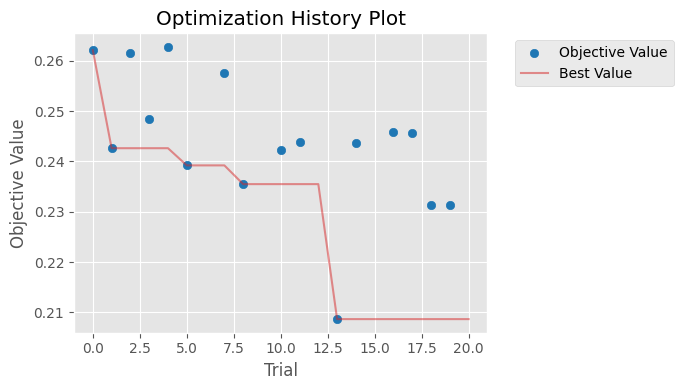

/tmp/ipykernel_1190/2835876261.py:22: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


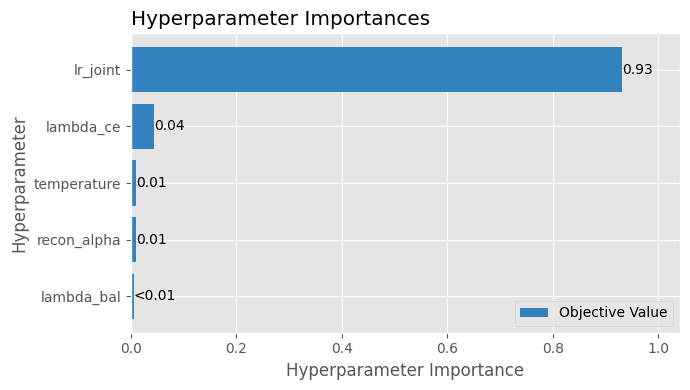

/tmp/ipykernel_1190/2835876261.py:22: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
/tmp/ipykernel_1190/2835876261.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(f"{T3}/optuna/{name}.png", dpi=150); plt.show()


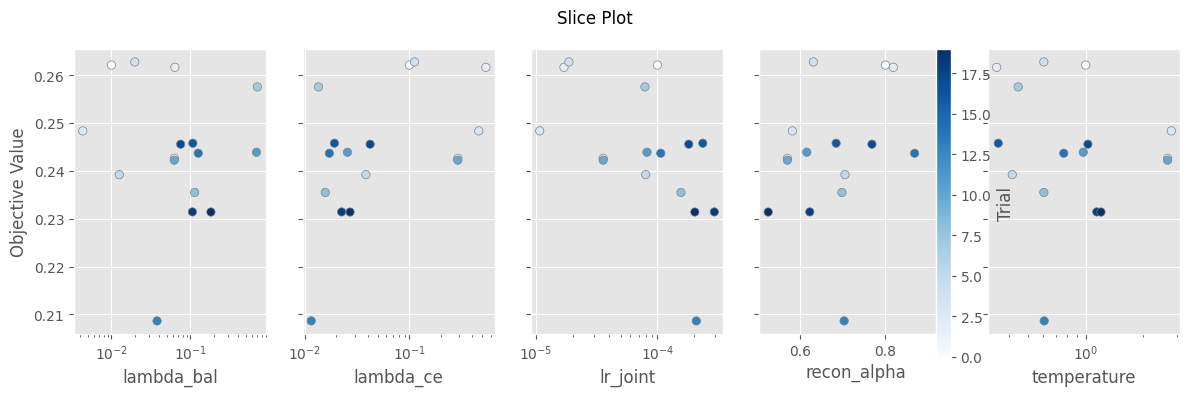

In [13]:
states = pd.Series([t.state.name for t in study.trials]).value_counts().to_dict()
best_t = study.best_trial
BEST_CFG = dict(best_t.params)
print("Trial states:", states)
print(f"Best trial #{best_t.number}: objective {best_t.value:.4f}")
print("Best config:", BEST_CFG)

df_trials = study.trials_dataframe()
df_trials.to_csv(f"{T3}/optuna/trials.csv", index=False)
json.dump({"search_space": SEARCH_SPACE, "fixed": {"batch_size": BATCH_SIZE, "warmup_lr": WARMUP_LR,
           "trial_warmup_epochs": OPTUNA_WARMUP_EPOCHS, "trial_joint_epochs": OPTUNA_JOINT_EPOCHS},
           "n_trials": len(study.trials), "states": states, "best_trial": best_t.number,
           "best_value": best_t.value, "best_params": BEST_CFG,
           "pruned_reasons": pd.Series([t.user_attrs.get("pruned_reason") for t in study.trials
                                        if t.state.name == "PRUNED"]).value_counts().to_dict()},
          open(f"{T3}/optuna/study_summary.json", "w"), indent=2)

from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice
for name, fn in [("history", plot_optimization_history), ("importance", plot_param_importances),
                 ("slice", plot_slice)]:
    try:
        ax = fn(study)
        fig = ax.figure if hasattr(ax, "figure") else ax.flatten()[0].figure
        fig.set_size_inches(12 if name == "slice" else 7, 4)
        fig.tight_layout(); fig.savefig(f"{T3}/optuna/{name}.png", dpi=150); plt.show()
    except Exception as e:
        print(f"Could not plot {name}: {e}")

## 6. Final training with the selected configuration

Longer schedule, early stopping on the validation objective (joint stage only), best checkpoint saved to Drive. The same eight validation images are logged to W&B every 5 epochs with their routing weights in the caption, so you can see the gate and experts change over time.

In [14]:
FINAL_CKPT = f"{T3}/checkpoints/soft_moe_best.pt"
best_obj, best_route, final_hist, _ = fit_moe(BEST_CFG, FINAL_WARMUP_EPOCHS, FINAL_JOINT_EPOCHS,
                                              "t3-final", "task3-final", ckpt_path=FINAL_CKPT,
                                              patience=PATIENCE, image_every=5)
pd.DataFrame(final_hist).to_csv(f"{T3}/results/final_history.csv", index=False)
print("Best validation objective:", round(best_obj, 4))

[t3-final] ep 01 warmup obj 0.2266 ssim 0.8147 gate_acc 0.856 shares [0.413, 0.25, 0.139, 0.198]
[t3-final] ep 02 warmup obj 0.2221 ssim 0.8181 gate_acc 0.807 shares [0.439, 0.25, 0.103, 0.209]
[t3-final] ep 03 warmup obj 0.2146 ssim 0.8247 gate_acc 0.764 shares [0.488, 0.244, 0.093, 0.176]
[t3-final] ep 04 joint  obj 0.2147 ssim 0.8262 gate_acc 0.618 shares [0.552, 0.245, 0.083, 0.121]
[t3-final] ep 05 joint  obj 0.2272 ssim 0.8120 gate_acc 0.692 shares [0.53, 0.212, 0.075, 0.183]
[t3-final] ep 06 joint  obj 0.2115 ssim 0.8268 gate_acc 0.640 shares [0.56, 0.232, 0.063, 0.145]
[t3-final] ep 07 joint  obj 0.2049 ssim 0.8334 gate_acc 0.558 shares [0.594, 0.243, 0.06, 0.104]
[t3-final] ep 08 joint  obj 0.2105 ssim 0.8298 gate_acc 0.594 shares [0.566, 0.233, 0.087, 0.115]
[t3-final] ep 09 joint  obj 0.2213 ssim 0.8142 gate_acc 0.572 shares [0.628, 0.171, 0.064, 0.138]
[t3-final] ep 10 joint  obj 0.2102 ssim 0.8267 gate_acc 0.614 shares [0.585, 0.211, 0.065, 0.14]
[t3-final] ep 11 joint  ob

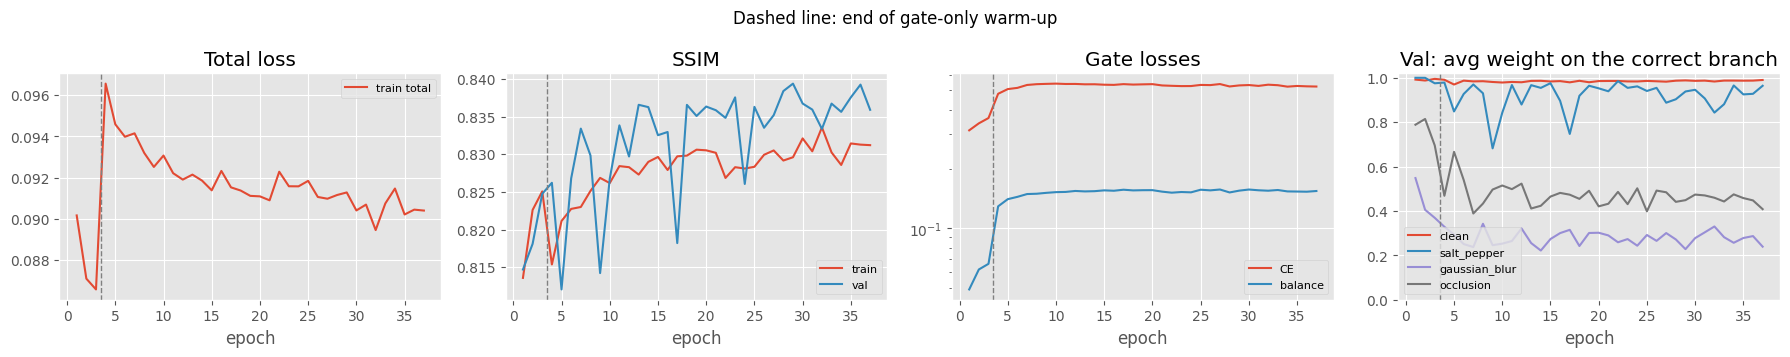

In [15]:
hist = pd.DataFrame(final_hist)
fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
ax[0].plot(hist.epoch, hist.train_loss, label="train total"); ax[0].set_title("Total loss")
ax[1].plot(hist.epoch, hist.train_ssim, label="train"); ax[1].plot(hist.epoch, hist.val_ssim, label="val")
ax[1].set_title("SSIM")
ax[2].plot(hist.epoch, hist.train_ce, label="CE"); ax[2].plot(hist.epoch, hist.train_balance, label="balance")
ax[2].set_title("Gate losses"); ax[2].set_yscale("log")
for b in BRANCHES:
    ax[3].plot(hist.epoch, hist[f"val_own_w_{b}"], label=b)
ax[3].set_title("Val: avg weight on the correct branch"); ax[3].set_ylim(0, 1.02)
for a in ax:
    a.axvline(FINAL_WARMUP_EPOCHS + 0.5, color="grey", ls="--", lw=1); a.set_xlabel("epoch"); a.legend(fontsize=8)
fig.suptitle("Dashed line: end of gate-only warm-up"); fig.tight_layout()
fig.savefig(f"{T3}/figures/training_curves.png", dpi=150); plt.show()

## 7. Test evaluation: soft MoE against hard routing

The official test manifest (10 entries per image) is used here for the first time. Five systems are compared on identical inputs:

- **No restoration**: the corrupted input itself.
- **Hard, predicted routing**: Task 2 classifier picks one Task 2 specialist (clean goes to the identity bypass).
- **Hard, oracle routing**: the true label picks the specialist (upper bound for hard routing).
- **Soft MoE at initialisation**: Task 2 components combined with soft weights at the selected T, before any joint training.
- **Soft MoE, jointly trained**: the final Task 3 model.

In [16]:
ckpt = torch.load(FINAL_CKPT, map_location="cpu", weights_only=False)
BEST_CFG = ckpt["config"]
final_model = build_moe(BEST_CFG["temperature"])
final_model.load_state_dict(ckpt["state_dict"]); final_model.eval()
init_model = build_moe(BEST_CFG["temperature"]).eval()
print(f"Loaded final model from epoch {ckpt['epoch']}, T = {BEST_CFG['temperature']:.3f}")

test_ds = ManifestDataset(test_images, test_entries)
test_loader = make_loader(test_ds, 128, False, NUM_WORKERS)
METHODS = ["input", "hard_pred", "hard_oracle", "soft_init", "soft_final"]
METHOD_NAMES = {"input": "No restoration", "hard_pred": "Hard (predicted)", "hard_oracle": "Hard (oracle)",
                "soft_init": "Soft MoE (init)", "soft_final": "Soft MoE (joint)"}

@torch.no_grad()
def run_test(loader):
    rows = {f"{m}_{k}": [] for m in METHODS for k in ("l1", "psnr", "ssim")}
    rows.update({"index": [], "cond": [], "pred_init": [], "pred_final": []})
    W_final, W_init = [], []
    for x, y, c, k in loader:
        x, y, c = x.to(device), y.to(device), c.to(device)
        ar = torch.arange(len(x), device=device)
        logits0 = init_model.gate(x)
        outs0 = init_model.branch_outputs(x)
        w0 = torch.softmax(logits0 / init_model.temperature, 1)
        pred0 = logits0.argmax(1)
        x_final, w1, _ = final_model(x)
        preds = {"input": x, "hard_pred": outs0[ar, pred0], "hard_oracle": outs0[ar, c],
                 "soft_init": (w0[:, :, None, None, None] * outs0).sum(1), "soft_final": x_final}
        for m, out in preds.items():
            met = per_sample_metrics(out, y)
            for kk in ("l1", "psnr", "ssim"):
                rows[f"{m}_{kk}"].append(met[kk].cpu().numpy())
        rows["index"].append(k.numpy()); rows["cond"].append(c.cpu().numpy())
        rows["pred_init"].append(pred0.cpu().numpy()); rows["pred_final"].append(w1.argmax(1).cpu().numpy())
        W_final.append(w1.cpu().numpy()); W_init.append(w0.cpu().numpy())
    df = pd.DataFrame({k: np.concatenate(v) for k, v in rows.items()})
    df["type"] = [test_entries[i]["type"] for i in df["index"]]
    df["severity"] = [test_entries[i]["severity"] for i in df["index"]]
    df["img_idx"] = [test_entries[i]["img_idx"] for i in df["index"]]
    W_final, W_init = np.concatenate(W_final), np.concatenate(W_init)
    for i, b in enumerate(BRANCHES):
        df[f"w_{b}"] = W_final[:, i]
        df[f"w0_{b}"] = W_init[:, i]
    return df

t0 = time.time()
res = run_test(test_loader)
res.to_csv(f"{T3}/results/test_per_sample.csv", index=False)
print(f"Evaluated {len(res)} test entries in {time.time() - t0:.0f} s")

Loaded final model from epoch 29, T = 0.607
Evaluated 36690 test entries in 920 s


In [ ]:
SEV_ORDER = {"none": 0, "low": 1, "medium": 2, "high": 3}

def summary_table(df, by):
    t = df.groupby(by)[[f"{m}_{k}" for m in METHODS for k in ("psnr", "ssim")]].mean()
    t.columns = pd.MultiIndex.from_tuples([(METHOD_NAMES[c.rsplit('_', 1)[0]], c.rsplit('_', 1)[1].upper())
                                           for c in t.columns])
    return t

by_cond = summary_table(res, "type").reindex(CONDITIONS)
overall = summary_table(res.assign(all="all"), "all")
by_cond = pd.concat([by_cond, overall.rename(index={"all": "overall"})])
by_sev = summary_table(res, ["type", "severity"])
by_sev = by_sev.iloc[sorted(range(len(by_sev)), key=lambda i: (CONDITIONS.index(by_sev.index[i][0]),
                                                                  SEV_ORDER[by_sev.index[i][1]]))]
for name, t in [("by_condition", by_cond), ("by_condition_severity", by_sev)]:
    t.to_csv(f"{T3}/results/{name}.csv")
    with open(f"{T3}/results/{name}.tex", "w") as f:
        f.write(t.to_latex(float_format="%.3f", multicolumn_format="c"))
pd.set_option("display.width", 250)
display(by_cond.round(3)); display(by_sev.round(3))

In [ ]:
# Where does the classifier get it wrong, and does soft routing recover?
mis = res[res.pred_init != res.cond]
cls_acc = (res.pred_init == res.cond).mean()
print(f"Task 2 classifier test accuracy: {cls_acc:.4f}  |  joint gate argmax accuracy: "
      f"{(res.pred_final == res.cond).mean():.4f}")
print(f"Misrouted by hard routing: {len(mis)} of {len(res)} entries")
if len(mis):
    t = mis.groupby(["type", "severity"])[["hard_pred_ssim", "hard_oracle_ssim", "soft_final_ssim"]].agg(["mean"])
    t["count"] = mis.groupby(["type", "severity"]).size()
    t.columns = ["hard_pred_SSIM", "hard_oracle_SSIM", "soft_final_SSIM", "count"]
    t.to_csv(f"{T3}/results/misrouted_cases.csv")
    display(t.round(3))
    print("Soft better than hard-predicted on misrouted entries:",
          f"{(mis.soft_final_ssim > mis.hard_pred_ssim).mean():.1%}")

## 8. Routing analysis

This section answers the questions the brief asks about the gate:

1. Average expert weights for every true corruption type and severity level (heatmap).
2. Weight distributions per true type.
3. Is any expert inactive, and does any expert dominate inputs it was not trained for?
4. Examples where one expert dominates and where weights are spread across several experts.
5. An extra stress test with two corruptions in one image, which is the case hard routing cannot represent.

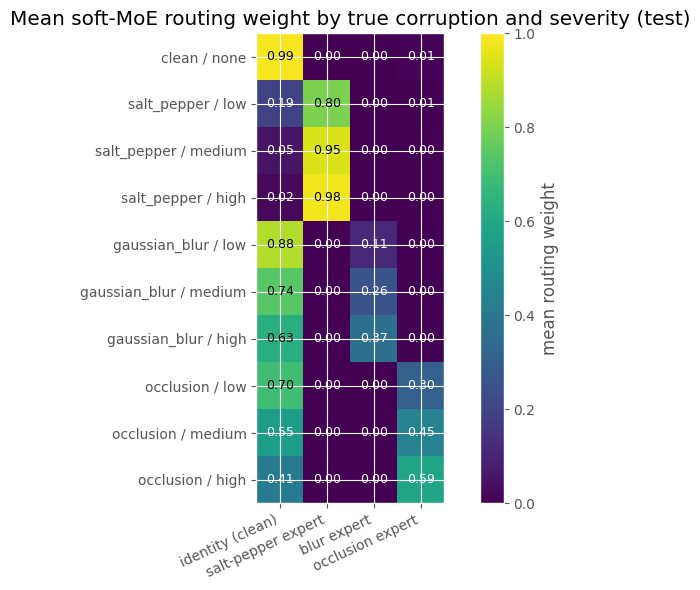

identity (clean)  salt-pepper expert  blur expert  occlusion expert
type          severity                                                                     
clean         none                 0.987               0.000        0.002             0.011
salt_pepper   low                  0.192               0.802        0.000             0.006
              medium               0.053               0.946        0.000             0.001
              high                 0.023               0.977        0.000             0.000
gaussian_blur low                  0.884               0.000        0.111             0.005
              medium               0.739               0.000        0.256             0.004
              high                 0.627               0.000        0.368             0.004
occlusion     low                  0.695               0.000        0.000             0.305
              medium               0.555               0.000        0.000             0.445
              high                 0.413               0.000        0.000             0.587

In [19]:
wcols = [f"w_{b}" for b in BRANCHES]
route_tbl = res.groupby(["type", "severity"])[wcols].mean()
route_tbl = route_tbl.iloc[sorted(range(len(route_tbl)), key=lambda i: (CONDITIONS.index(route_tbl.index[i][0]),
                                                                        SEV_ORDER[route_tbl.index[i][1]]))]
route_tbl.columns = ["identity (clean)", "salt-pepper expert", "blur expert", "occlusion expert"]
route_tbl.to_csv(f"{T3}/results/routing_by_type_severity.csv")
with open(f"{T3}/results/routing_by_type_severity.tex", "w") as f:
    f.write(route_tbl.to_latex(float_format="%.3f"))

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(route_tbl.values, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(4)); ax.set_xticklabels(route_tbl.columns, rotation=25, ha="right")
ax.set_yticks(range(len(route_tbl))); ax.set_yticklabels([f"{t} / {s}" for t, s in route_tbl.index])
for i in range(route_tbl.shape[0]):
    for j in range(4):
        v = route_tbl.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black" if v > 0.6 else "white", fontsize=9)
fig.colorbar(im, ax=ax, label="mean routing weight")
ax.set_title("Mean soft-MoE routing weight by true corruption and severity (test)")
fig.tight_layout(); fig.savefig(f"{T3}/figures/routing_heatmap.png", dpi=150); plt.show()
display(route_tbl.round(3))

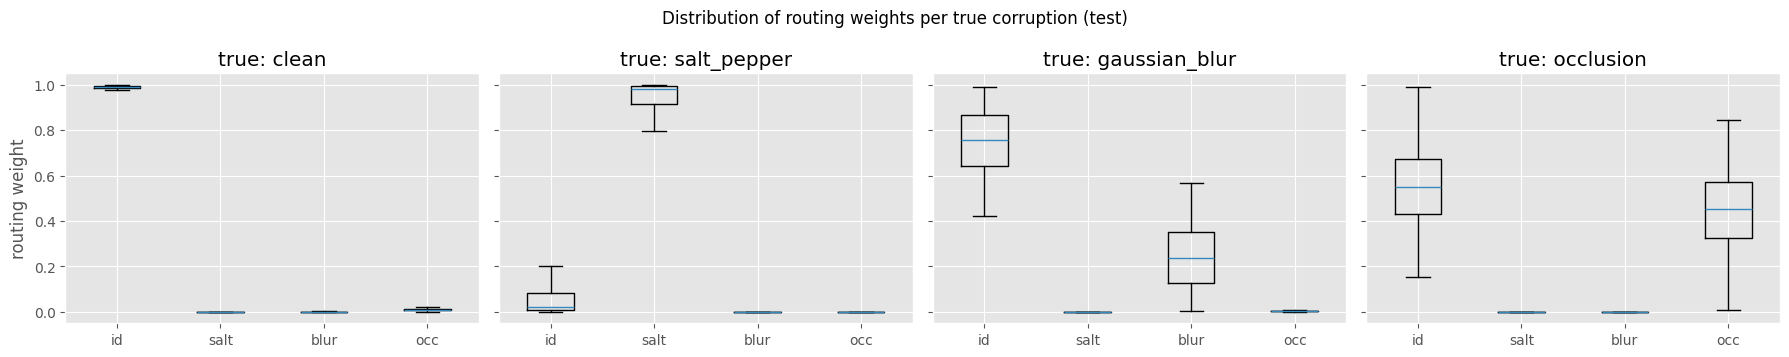

,mean_weight_all,argmax_share,mean_weight_own_type,mean_weight_other_types,max_weight_seen
branch,,,,,
clean,0.517,0.593,0.987,0.465,0.998
salt_pepper,0.273,0.286,0.908,0.000,1.000
gaussian_blur,0.074,0.001,0.245,0.000,0.567
occlusion,0.137,0.120,0.446,0.005,0.844


Check finished. No warning means every branch is used and none dominates unrelated inputs.


In [20]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6), sharey=True)
for ax, t in zip(axes, CONDITIONS):
    sub = res[res.type == t]
    ax.boxplot([sub[c].values for c in wcols], showfliers=False)
    ax.set_xticks(range(1, 5)); ax.set_xticklabels(["id", "salt", "blur", "occ"])
    ax.set_title(f"true: {t}")
axes[0].set_ylabel("routing weight")
fig.suptitle("Distribution of routing weights per true corruption (test)"); fig.tight_layout()
fig.savefig(f"{T3}/figures/routing_distributions.png", dpi=150); plt.show()

# Inactive or dominant experts
rows = []
for i, b in enumerate(BRANCHES):
    own = res[res.type == b][f"w_{b}"].mean()
    other = res[res.type != b][f"w_{b}"].mean()
    rows.append({"branch": b, "mean_weight_all": res[f"w_{b}"].mean(),
                 "argmax_share": (res[wcols].values.argmax(1) == i).mean(),
                 "mean_weight_own_type": own, "mean_weight_other_types": other,
                 "max_weight_seen": res[f"w_{b}"].max()})
usage = pd.DataFrame(rows).set_index("branch")
usage.to_csv(f"{T3}/results/expert_usage.csv")
display(usage.round(3))
for b, r in usage.iterrows():
    if r.mean_weight_all < COLLAPSE_MIN_SHARE or r.max_weight_seen < 0.5:
        print(f"WARNING: branch '{b}' looks inactive")
    if r.mean_weight_other_types > 0.25:
        print(f"WARNING: branch '{b}' takes a large share ({r.mean_weight_other_types:.2f}) of unrelated inputs")
print("Check finished. No warning means every branch is used and none dominates unrelated inputs.")

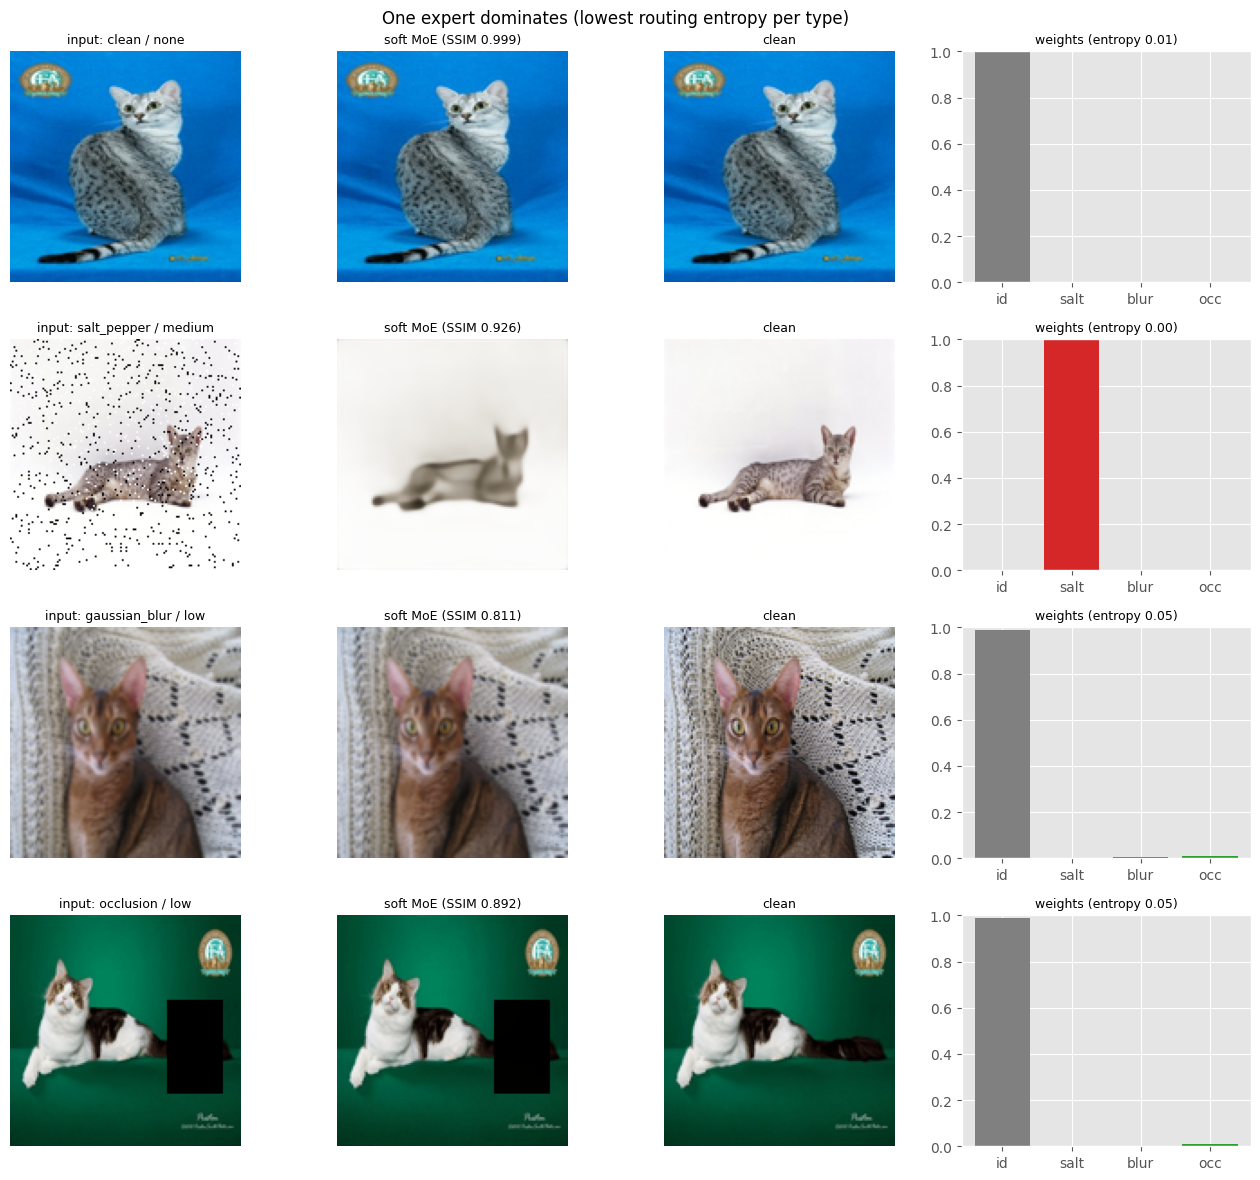

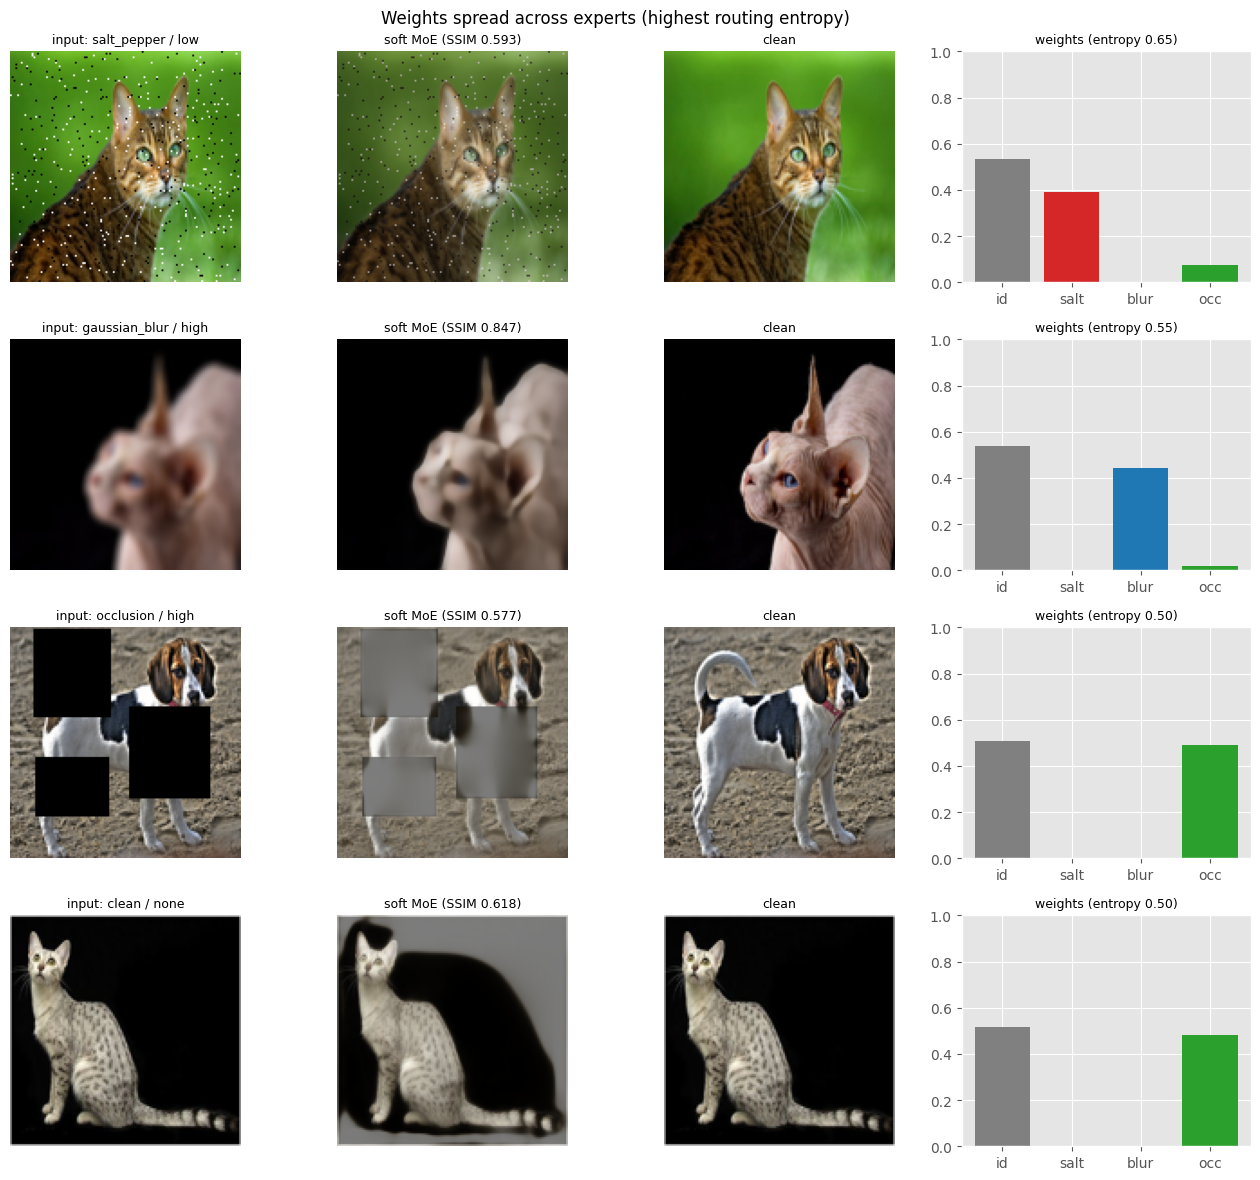

In [21]:
H = -(res[wcols].clip(1e-8, 1) * np.log(res[wcols].clip(1e-8, 1))).sum(1) / np.log(4)
res["route_entropy"] = H
corr = res[res.type != "clean"]
dominant = [corr[corr.type == t].sort_values("route_entropy").iloc[0] for t in CONDITIONS[1:]]
dominant.insert(0, res[res.type == "clean"].sort_values("route_entropy").iloc[0])
distributed = res.sort_values("route_entropy", ascending=False).drop_duplicates("type").head(4)
distributed = [r for _, r in distributed.iterrows()]

@torch.no_grad()
def show_routed_examples(rows_, title, path):
    fig, axes = plt.subplots(len(rows_), 4, figsize=(13, 3 * len(rows_)))
    for r_i, r in enumerate(rows_):
        x, y, _, _ = test_ds[int(r["index"])]
        out, w, _ = final_model(x[None].to(device))
        out, w = out[0].cpu(), w[0].cpu().numpy()
        for a, im, t in zip(axes[r_i][:3], [x, out, y],
                            [f"input: {r['type']} / {r['severity']}", f"soft MoE (SSIM {r['soft_final_ssim']:.3f})", "clean"]):
            a.imshow(im.permute(1, 2, 0).clamp(0, 1)); a.set_title(t, fontsize=9); a.axis("off")
        a = axes[r_i][3]
        a.bar(["id", "salt", "blur", "occ"], w, color=["grey", "tab:red", "tab:blue", "tab:green"])
        a.set_ylim(0, 1); a.set_title(f"weights (entropy {r['route_entropy']:.2f})", fontsize=9)
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path, dpi=130); plt.show()

show_routed_examples(dominant, "One expert dominates (lowest routing entropy per type)", f"{T3}/figures/routing_dominant.png")
show_routed_examples(distributed, "Weights spread across experts (highest routing entropy)", f"{T3}/figures/routing_distributed.png")

In [22]:
# Extra stress test: two corruptions in one image (medium levels, fixed from the test manifest)
MIX_PAIRS = [("gaussian_blur", "salt_pepper"), ("gaussian_blur", "occlusion"), ("salt_pepper", "occlusion")]
N_MIX = min(300, len(test_images))
by_img = {}
for e in test_entries:
    if e["severity"] == "medium":
        by_img.setdefault(e["img_idx"], {})[e["type"]] = e

@torch.no_grad()
def eval_mixed():
    out_rows = []
    for a, b in MIX_PAIRS:
        xs, ys = [], []
        for i in range(N_MIX):
            clean = test_images[i].astype(np.float32) / 255.0
            img = apply_corruption(apply_corruption(clean, by_img[i][a]), by_img[i][b])
            xs.append(torch.from_numpy(img.transpose(2, 0, 1).copy()).float())
            ys.append(torch.from_numpy(clean.transpose(2, 0, 1).copy()).float())
        x, y = torch.stack(xs).to(device), torch.stack(ys).to(device)
        for s in range(0, len(x), 100):
            xb, yb = x[s:s+100], y[s:s+100]
            ar = torch.arange(len(xb), device=device)
            logits0 = init_model.gate(xb); outs0 = init_model.branch_outputs(xb)
            hard = outs0[ar, logits0.argmax(1)]
            soft, w, _ = final_model(xb)
            m_in, m_h, m_s = (per_sample_metrics(o, yb)["ssim"].cpu().numpy() for o in (xb, hard, soft))
            for j in range(len(xb)):
                out_rows.append({"pair": f"{a}+{b}", "input_ssim": m_in[j], "hard_pred_ssim": m_h[j],
                                 "soft_final_ssim": m_s[j], **{f"w_{br}": w[j, k].item() for k, br in enumerate(BRANCHES)}})
    return pd.DataFrame(out_rows)

mixed = eval_mixed()
mix_tbl = mixed.groupby("pair").mean(numeric_only=True)
mix_tbl.to_csv(f"{T3}/results/mixed_corruptions.csv")
with open(f"{T3}/results/mixed_corruptions.tex", "w") as f:
    f.write(mix_tbl.to_latex(float_format="%.3f"))
display(mix_tbl.round(3))

,input_ssim,hard_pred_ssim,soft_final_ssim,w_clean,w_salt_pepper,w_gaussian_blur,w_occlusion
pair,,,,,,,
gaussian_blur+occlusion,0.588,0.632,0.644,0.534,0.000,0.0,0.466
gaussian_blur+salt_pepper,0.241,0.697,0.691,0.006,0.994,0.0,0.000
salt_pepper+occlusion,0.254,0.435,0.390,0.545,0.442,0.0,0.012


## 9. Visual results and failure cases

Twelve representative examples: three clean inputs and one per corruption and severity (nine). Each is the test entry closest to the median soft-MoE SSIM of its group, so they are typical rather than best cases. Each row shows the clean target, corrupted input, restored output, absolute error map and the routing weights.

Failure cases: the four lowest soft-MoE SSIM entries from different conditions, plus four cases where a hard-routing classifier error caused a large restoration loss.

In [ ]:
def pick_median(df):
    med = df.soft_final_ssim.median()
    return df.iloc[(df.soft_final_ssim - med).abs().argsort().values]

reps = list(pick_median(res[res.type == "clean"]).drop_duplicates("img_idx").head(3).itertuples())
for t in CONDITIONS[1:]:
    for s in ("low", "medium", "high"):
        reps.append(next(pick_median(res[(res.type == t) & (res.severity == s)]).itertuples()))

@torch.no_grad()
def show_grid(rows_, title, path, show_hard=False):
    ncol = 6 if show_hard else 5
    fig, axes = plt.subplots(len(rows_), ncol, figsize=(2.6 * ncol, 2.6 * len(rows_)))
    for r_i, r in enumerate(rows_):
        x, y, _, _ = test_ds[int(r.index)]
        xb = x[None].to(device)
        out, w, _ = final_model(xb)
        out, w = out[0].cpu(), w[0].cpu().numpy()
        err = (out - y).abs().mean(0)
        panels = [(y, "clean target"), (x, f"{r.type} / {r.severity}"), (out, f"soft MoE {r.soft_final_ssim:.3f}")]
        if show_hard:
            ar = torch.arange(1, device=device)
            hard = init_model.branch_outputs(xb)[ar, init_model.gate(xb).argmax(1)][0].cpu()
            panels.append((hard, f"hard -> {BRANCHES[int(r.pred_init)]} {r.hard_pred_ssim:.3f}"))
        for a, (im, t) in zip(axes[r_i], panels):
            a.imshow(im.permute(1, 2, 0).clamp(0, 1)); a.set_title(t, fontsize=8); a.axis("off")
        a = axes[r_i][len(panels)]
        a.imshow(err, cmap="inferno", vmin=0, vmax=0.5); a.set_title("|error| (soft)", fontsize=8); a.axis("off")
        a = axes[r_i][len(panels) + 1]
        a.bar(["id", "s", "b", "o"], w, color=["grey", "tab:red", "tab:blue", "tab:green"]); a.set_ylim(0, 1)
        a.set_title("weights", fontsize=8)
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path, dpi=120); plt.show()

show_grid(reps, "Representative test results (median SSIM per group)", f"{T3}/figures/representative_12.png")

worst = res[res.type != "clean"].sort_values("soft_final_ssim")
fails = list(worst.drop_duplicates("type").itertuples()) + list(worst[~worst.index.isin(worst.drop_duplicates("type").index)].head(1).itertuples())
show_grid(fails[:4], "Failure cases: lowest soft-MoE SSIM", f"{T3}/figures/failures_soft.png")

misr = res[(res.pred_init != res.cond)].assign(drop=lambda d: d.hard_oracle_ssim - d.hard_pred_ssim)
if len(misr):
    show_grid(list(misr.sort_values("drop", ascending=False).drop_duplicates("type").head(4).itertuples()),
              "Classifier errors in hard routing vs soft MoE", f"{T3}/figures/failures_hard_routing.png", show_hard=True)

## 10. ONNX export of the complete soft MoE pipeline

One ONNX graph contains the gate, softmax with temperature, identity branch, three experts and the weighted sum. Input: `input` (N, 3, 128, 128), RGB in [0, 1]. Outputs: `restored`, `weights` (order: identity, salt-pepper, blur, occlusion) and `logits`. The export is checked against PyTorch on 80 real test images.

In [ ]:
import onnx, onnxruntime as ort
ONNX_PATH = f"{T3}/onnx/soft_moe.onnx"
export_model = build_moe(BEST_CFG["temperature"]).cpu()
export_model.load_state_dict(ckpt["state_dict"]); export_model.eval()
dummy = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
torch.onnx.export(export_model, dummy, ONNX_PATH, input_names=["input"],
                  output_names=["restored", "weights", "logits"], opset_version=17,
                  dynamic_axes={"input": {0: "batch"}, "restored": {0: "batch"},
                                "weights": {0: "batch"}, "logits": {0: "batch"}}, dynamo=False)
onnx.checker.check_model(onnx.load(ONNX_PATH))
sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

step = max(1, len(test_ds) // 80)
xs = torch.stack([test_ds[i][0] for i in range(0, len(test_ds), step)][:80])
with torch.no_grad():
    pt = export_model(xs)
ox = sess.run(None, {"input": xs.numpy()})
diffs = {n: float(np.abs(p.numpy() - o).max()) for n, p, o in zip(["restored", "weights", "logits"], pt, ox)}
print("Max |PyTorch - ONNX| on 80 test images:", diffs)
assert diffs["restored"] < 1e-4 and diffs["weights"] < 1e-4, "ONNX output does not match PyTorch"

one = xs[:1].numpy()
for _ in range(5): sess.run(None, {"input": one})
lat = []
for _ in range(50):
    t0 = time.perf_counter(); sess.run(None, {"input": one}); lat.append((time.perf_counter() - t0) * 1000)
print(f"ONNX Runtime CPU latency (batch 1): mean {np.mean(lat):.1f} ms, p95 {np.percentile(lat, 95):.1f} ms")

meta = {"task": "soft_moe_restoration", "onnx_file": "soft_moe.onnx", "input": {"name": "input", "shape": [None, 3, IMG_SIZE, IMG_SIZE],
        "range": [0, 1], "layout": "NCHW RGB float32"},
        "outputs": {"restored": "NCHW RGB in [0,1]", "weights": "softmax(logits/T), branch order below", "logits": "raw gate logits"},
        "branches": BRANCHES, "branch_labels": ["Identity (clean)", "Salt-and-pepper expert", "Gaussian blur expert", "Occlusion expert"],
        "temperature": BEST_CFG["temperature"], "config": BEST_CFG, "opset": 17,
        "onnx_vs_pytorch_max_abs_diff": diffs, "cpu_latency_ms_batch1": {"mean": float(np.mean(lat)), "p95": float(np.percentile(lat, 95))},
        "test_ssim": float(res.soft_final_ssim.mean()), "test_psnr": float(res.soft_final_psnr.mean())}
json.dump(meta, open(f"{T3}/onnx/task3_metadata.json", "w"), indent=2)
print("Saved", ONNX_PATH, f"({os.path.getsize(ONNX_PATH) / 1e6:.1f} MB)")

## 11. Log results and files to W&B

In [ ]:
def flat(df):
    d = df.round(4).copy()
    d.columns = [" ".join(map(str, c)) if isinstance(c, tuple) else str(c) for c in d.columns]
    d.index = [" / ".join(map(str, i)) if isinstance(i, tuple) else str(i) for i in d.index]
    return d.reset_index(names="group")

run = wandb.init(project=WANDB_PROJECT, name="t3-test-and-export", group="task3-final", job_type="task3-eval", reinit=True)
wandb.log({"test/by_condition": wandb.Table(dataframe=flat(by_cond)),
           "test/by_condition_severity": wandb.Table(dataframe=flat(by_sev)),
           "test/routing_by_type_severity": wandb.Table(dataframe=flat(route_tbl)),
           "test/expert_usage": wandb.Table(dataframe=flat(usage)),
           "test/mixed_corruptions": wandb.Table(dataframe=flat(mix_tbl))})
for f in sorted(glob.glob(f"{T3}/figures/*.png")):
    wandb.log({f"figures/{os.path.basename(f)[:-4]}": wandb.Image(f)})
wandb.summary.update({"test_ssim_soft": float(res.soft_final_ssim.mean()), "test_ssim_hard_pred": float(res.hard_pred_ssim.mean()),
                      "test_ssim_hard_oracle": float(res.hard_oracle_ssim.mean()), "onnx_latency_ms": float(np.mean(lat))})
art = wandb.Artifact("task3-soft-moe", type="model")
for f in [FINAL_CKPT, ONNX_PATH, f"{T3}/onnx/task3_metadata.json", f"{T3}/optuna/study_summary.json"]:
    art.add_file(f)
art.add_dir(f"{T3}/results", name="results")
run.log_artifact(art); run.finish()
print("Task 3 complete. Everything is in", T3)